## rx1day - newcastle

In [2]:
import glob

import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import numpy as np

from unseen import process_utils
from unseen import eva

In [3]:
#from importlib import reload

In [4]:
#reload(eva)

In [5]:
region = 'Newcastle'

In [6]:
ds = xr.open_dataset('/g/data/xv83/unseen-projects/outputs/pasha/data/rx1day_AGCD-CSIRO_1901-2024_YE-AUG_pasha-lgas.nc')
ds = ds.sel(region=region)

In [7]:
ds

<xarray.Dataset> Size: 7kB
Dimensions:     (time: 124)
Coordinates:
    region      <U19 76B 'Newcastle'
  * time        (time) datetime64[ns] 992B 1901-01-01 1902-01-01 ... 2024-01-01
    event_time  (time) <U10 5kB ...
Data variables:
    pr          (time) float32 496B ...
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       1899-12-31T09:00:00
    date_created:              2017-01-17T22:13:51.976225
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2025-02-06 02:46:57
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2025, ...
    history:                   Wed Sep 03 13:42:55 2025: /g/data/xv83/dbi599/...

In [8]:
df = ds.to_dataframe()
df.index = df.index.year

In [9]:
df

,pr,region,event_time
time,,,
1901,42.985699,Newcastle,1900-11-20
1902,47.840984,Newcastle,1901-10-10
1903,104.486092,Newcastle,1902-10-13
1904,145.922379,Newcastle,1903-09-28
1905,52.700214,Newcastle,1905-03-04
...,...,...,...
2020,111.314468,Newcastle,2020-07-27
2021,72.207542,Newcastle,2021-03-19
2022,75.469658,Newcastle,2022-07-06


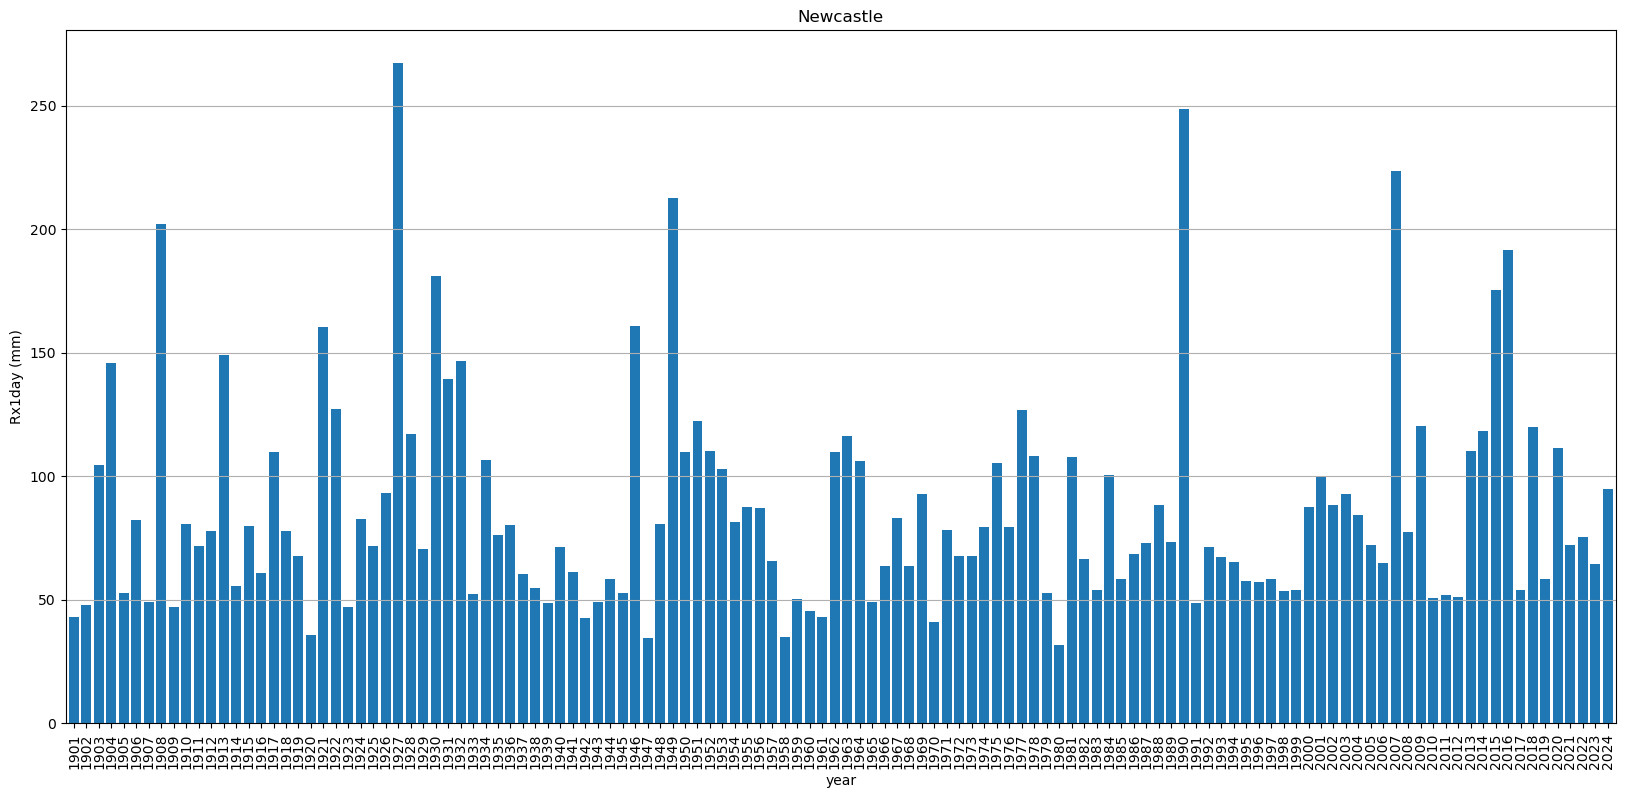

In [10]:
df['pr'].plot.bar(figsize=[20, 9], width=0.8)
plt.ylabel('Rx1day (mm)')
plt.xlabel('year')
plt.title(region)
plt.grid(axis='y')
plt.show()

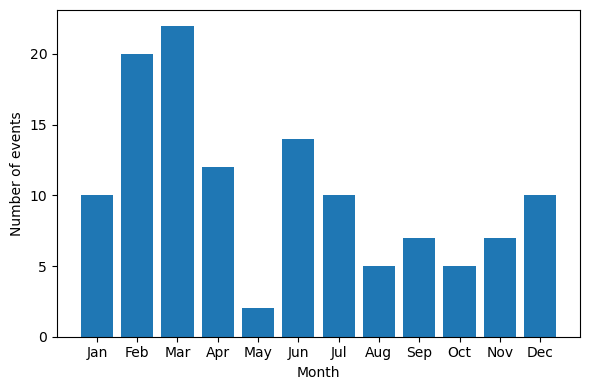

In [11]:
fig = plt.figure(figsize=[6, 4])
ax = fig.add_subplot()
process_utils.plot_event_seasonality(ds, ax=ax)
plt.show()

In [12]:
ranked_years = df.sort_values(by='pr', ascending=False)
print(ranked_years.head(n=10))

              pr     region  event_time
time                                   
1927  267.160828  Newcastle  1927-04-16
1990  248.697556  Newcastle  1990-02-03
2007  223.518265  Newcastle  2007-06-09
1949  212.763535  Newcastle  1949-06-18
1908  202.109497  Newcastle  1908-02-24
2016  191.655472  Newcastle  2016-01-06
1930  181.095154  Newcastle  1930-06-17
2015  175.265976  Newcastle  2015-04-22
1946  160.756119  Newcastle  1946-04-19
1921  160.557022  Newcastle  1920-12-10


In [17]:
rx1day_2007 = float(ds['pr'].sel(time='2007-01-01').values)
rx1day_2007

223.5182647705078

In [18]:
dparams_s = eva.fit_gev(ds['pr'])

In [19]:
dparams_s

<xarray.DataArray 'pr' (dparams: 3)> Size: 24B
array([-0.24352252, 65.54467789, 24.71432702])
Coordinates:
    region   <U19 76B 'Newcastle'
  * dparams  (dparams) <U8 96B 'c' 'location' 'scale'
Attributes:
    long_name:    Genextreme parameters
    description:  Parameters of the genextreme distribution
    method:       MLE
    estimator:    LMM
    scipy_dist:   genextreme
    units:

In [20]:
dparams_ns = eva.fit_gev(
    ds['pr'],
    stationary=False,
    covariate=ds['time'],
    pick_best_model=True
)

/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),


In [21]:
dparams_ns

<xarray.DataArray (dparams: 5)> Size: 40B
array([-2.56677724e-01,  6.57312180e+01,  1.04502620e-04,  2.53272422e+01,
       -1.51745919e-04])
Coordinates:
    region   <U19 76B 'Newcastle'
  * dparams  (dparams) <U10 200B 'c' 'location_0' ... 'scale_0' 'scale_1'
Attributes:
    long_name:    Nonstationary genextreme parameters
    description:  Parameters of the nonstationary genextreme distribution
    method:       MLE
    estimator:    LMM
    scipy_dist:   genextreme
    units:

48 year return period
95% CI: 23-153 years


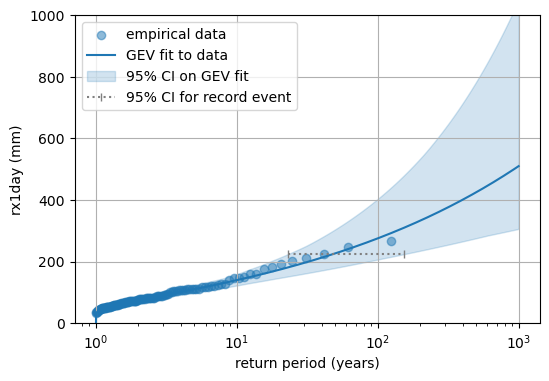

In [22]:
fig = plt.figure(figsize=[6, 4])
ax = fig.add_subplot()
eva.plot_gev_return_curve(
    ax,
    ds['pr'].values,
    rx1day_2007,
    direction="exceedance",
    bootstrap_method='parametric',
    n_bootstraps=100,
    max_return_period=3,
    ylabel='rx1day (mm)',
    ylim=(0, 1000),
)
plt.show()

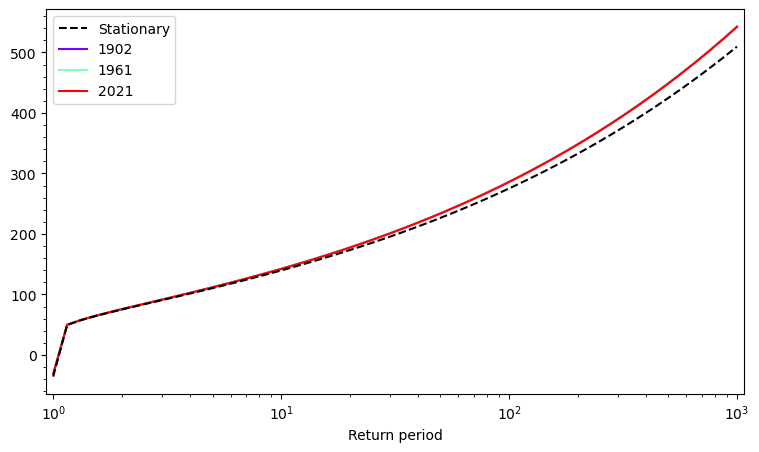

In [23]:
eva.plot_nonstationary_return_curve(
    xr.DataArray(np.logspace(0, 3)),
    dparams_s,
    dparams_ns,
    ds['time'].isel(time=[1, 60, 120]).dt.year,
)
plt.show()

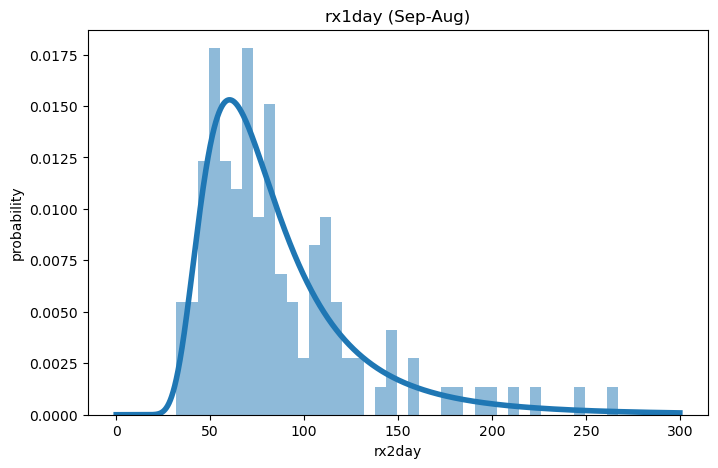

In [25]:
fig, ax = plt.subplots(figsize=[8, 5])
gev_xvals = np.arange(0, 300, 0.1)
shape, loc, scale = dparams_s

ds['pr'].plot.hist(bins=40, density=True, color='tab:blue', alpha=0.5)
pdf = gev.pdf(gev_xvals, shape, loc, scale)
plt.plot(gev_xvals, pdf, color='tab:blue', linewidth=4.0, label='AGCD')

plt.xlabel('rx2day')
plt.ylabel('probability')
plt.title(f'rx1day (Sep-Aug)')
#plt.xlim(xmin, xmax)
plt.show()

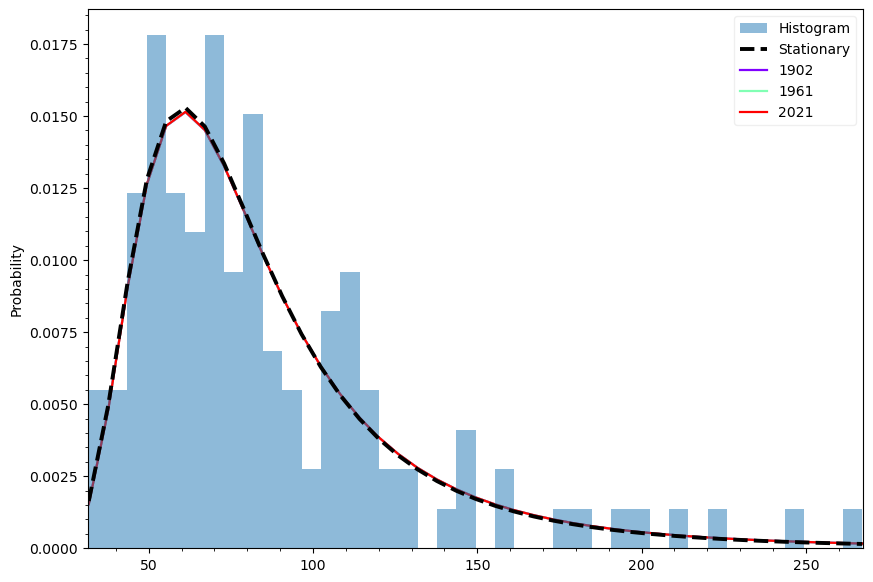

In [26]:
eva.plot_nonstationary_pdfs(
    ds['pr'],
    dparams_s,
    dparams_ns,
    ds['time'].isel(time=[1, 60, 120]).dt.year,
)
plt.show()